#1. Preparação dos dados

##Importação e unificação

In [48]:
import pandas as pd
import os

# 1. Configurações base
base_url = "https://github.com/Projeto-Aplicado-2-Mackenzie/analise-sentimento/blob/main/dataset/"
lista_df = []

print("Iniciando o download e a unificação dos 6 arquivos...")

# 2. Loop de 1 a 6
for i in range(1, 7):
    nome_arquivo = f"arquivo_parte_{i}.csv"
    url_download = f"{base_url}{nome_arquivo}?raw=true"

    # Baixa o arquivo silenciosamente (-q) e sobrescreve se já existir (-O)
    !wget -q -O {nome_arquivo} "{url_download}"

    tamanho = os.path.getsize(nome_arquivo)

    if tamanho > 100:
        try:
            # Lendo com engine 'python' para detectar automaticamente se o separador é ',' ou ';'
            df_temp = pd.read_csv(nome_arquivo, sep=None, engine='python', encoding='utf-8')
            lista_df.append(df_temp)
            print(f"{nome_arquivo} lido com sucesso! ({len(df_temp)} linhas)")
        except Exception as e:
            print(f"Erro ao processar {nome_arquivo}: {e}")
    else:
        print(f"{nome_arquivo} ignorado (está vazio ou com erro no GitHub - {tamanho} bytes)")

# 3. Concatenando todos os arquivos em um único DataFrame
if lista_df:
    df_final = pd.concat(lista_df, ignore_index=True)
    print("\n" + "="*30)
    print(f"PROCESSO CONCLUÍDO!")
    print(f"Total de linhas consolidadas: {len(df_final)}")
    print("="*30)
else:
    print("\nErro: Nenhum dado válido foi encontrado para criar o DataFrame.")

Iniciando o download e a unificação dos 6 arquivos...
arquivo_parte_1.csv lido com sucesso! (7696 linhas)
arquivo_parte_2.csv lido com sucesso! (7696 linhas)
arquivo_parte_3.csv lido com sucesso! (7696 linhas)
arquivo_parte_4.csv lido com sucesso! (7695 linhas)
arquivo_parte_5.csv lido com sucesso! (7695 linhas)
arquivo_parte_6.csv lido com sucesso! (7695 linhas)

PROCESSO CONCLUÍDO!
Total de linhas consolidadas: 46173


##Prévia

In [49]:
# Exibe as primeiras linhas do resultado final
display(df_final.head())

,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
0,0,3.0,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
1,1,4.0,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
2,2,4.0,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
3,3,5.0,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
4,4,5.0,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation


##Limpeza de colunas não utilizadas

In [50]:
# Remove colunas que não serão trabalhadas
df_final = df_final.drop(columns=['Unnamed: 0', 'Description', 'Reviews', 'emotion'], errors='ignore')

# Exibe para conferir
display(df_final.head())

,Ratings,movie_name,Resenhas,genres
0,3.0,Waiting to Exhale,"Riu algumas risadas, mas no geral a motivação ...","['Comedy', 'Drama', 'Romance']"
1,4.0,Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']"
2,4.0,Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']"
3,5.0,Waiting to Exhale,"O filme é bom, medíocre pode até ser a palavra...","['Comedy', 'Drama', 'Romance']"
4,5.0,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']"


#2. Visualizações gerais

## Visualização de volume por gênero  

###Visão geral

/tmp/ipykernel_4897/1780476579.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


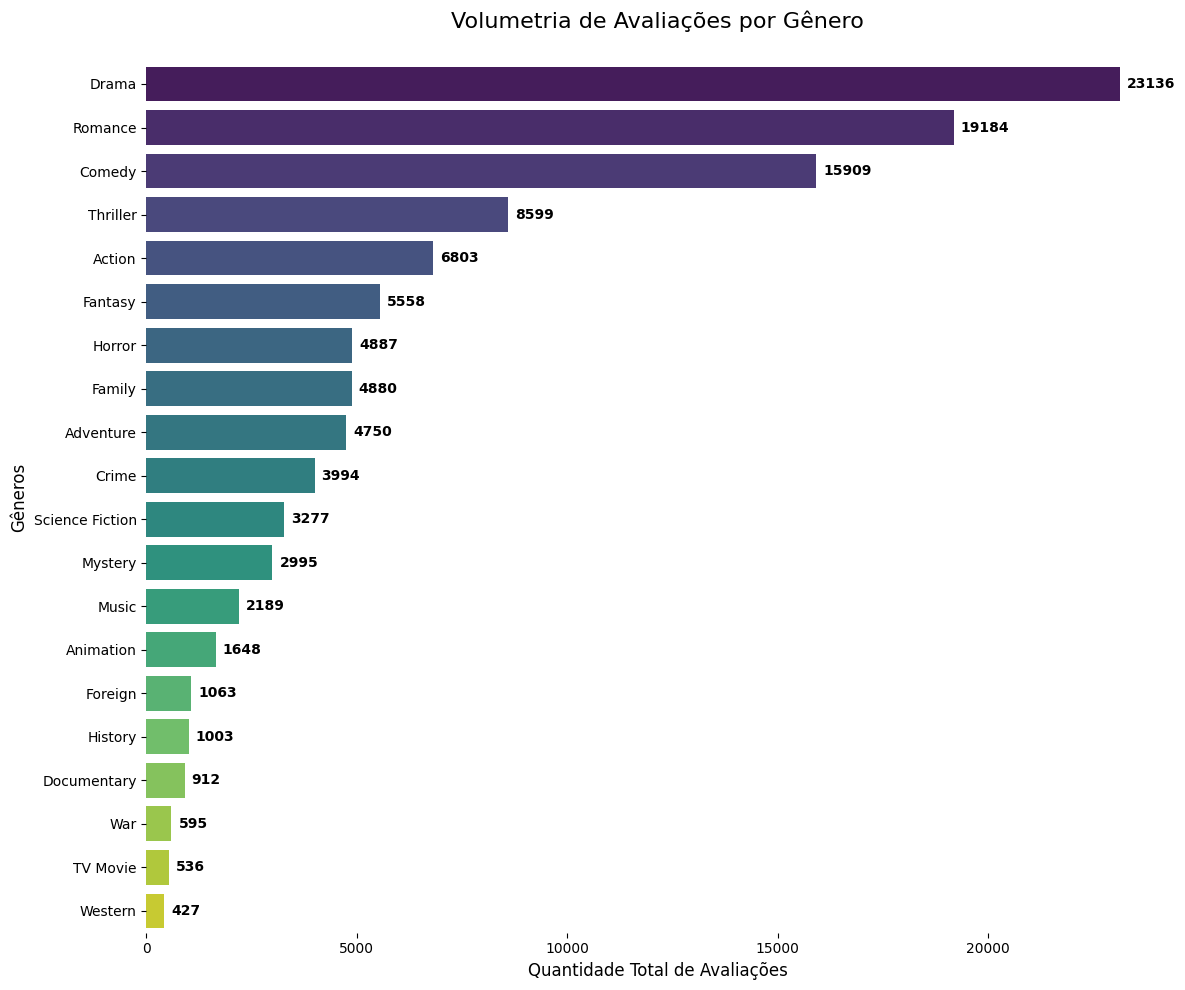

In [51]:
# 1. Preparação dos dados
generos_explodidos = df.explode('genres').reset_index(drop=True)

# 2. Configuração do tamanho da figura
plt.figure(figsize=(12, 10)) # Aumentei um pouco a altura para os rótulos não ficarem apertados

# 3. Criação do gráfico
ax = sns.countplot(
    y='genres',
    data=generos_explodidos,
    order=generos_explodidos['genres'].value_counts().index,
    palette='viridis'
)

# 4. APLICANDO O RÓTULO EM TODAS AS BARRAS (LOOP)
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, fontweight='bold')

# 5. Ajustes finais
plt.title("Volumetria de Avaliações por Gênero", fontsize=16, pad=25)
plt.xlabel("Quantidade Total de Avaliações", fontsize=12)
plt.ylabel("Gêneros", fontsize=12)

# Deixa as bordas mais limpas
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

###Visão percentual

/tmp/ipykernel_4897/823006203.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


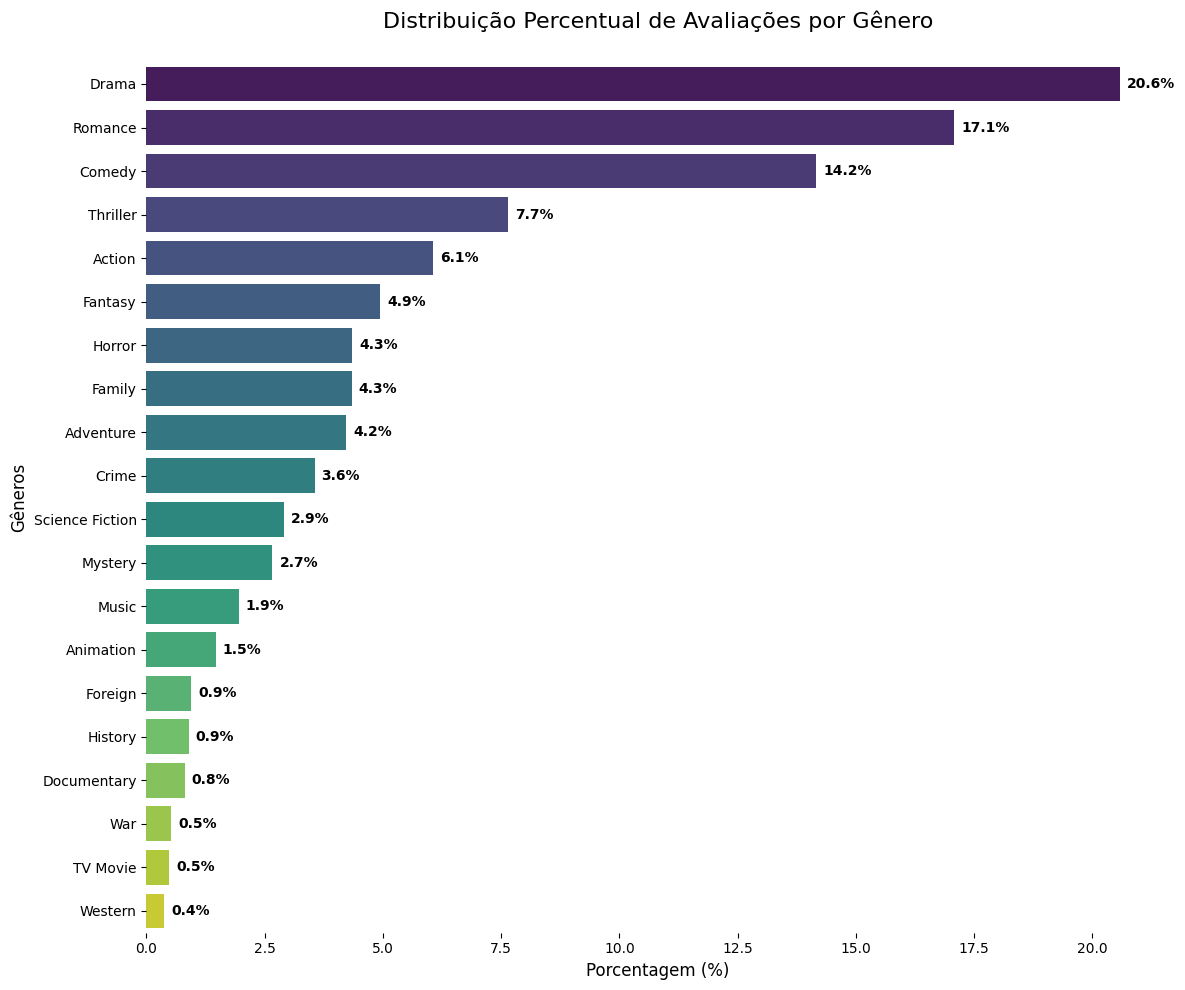

In [52]:
# 1. Preparação dos dados e cálculo do percentual
generos_explodidos = df.explode('genres').reset_index(drop=True)

# Calculamos a frequência relativa (normalize=True) e multiplicamos por 100
df_percent = (generos_explodidos['genres'].value_counts(normalize=True) * 100).reset_index()
df_percent.columns = ['genres', 'percentage']

# 2. Configuração do gráfico
plt.figure(figsize=(12, 10))

# 3. Criação do gráfico de barras
ax = sns.barplot(
    x='percentage',
    y='genres',
    data=df_percent,
    palette='viridis'
)

# 4. ADICIONANDO OS RÓTULOS PERCENTUAIS EM TODAS AS BARRAS
# O parâmetro fmt='%.1f%%' formata o número com uma casa decimal e o símbolo %
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=10, fontweight='bold')

# 5. Ajustes de títulos e eixos
plt.title("Distribuição Percentual de Avaliações por Gênero", fontsize=16, pad=25)
plt.xlabel("Porcentagem (%)", fontsize=12)
plt.ylabel("Gêneros", fontsize=12)

# Limpeza visual
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

###Word Cloud por nota de avaliação

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


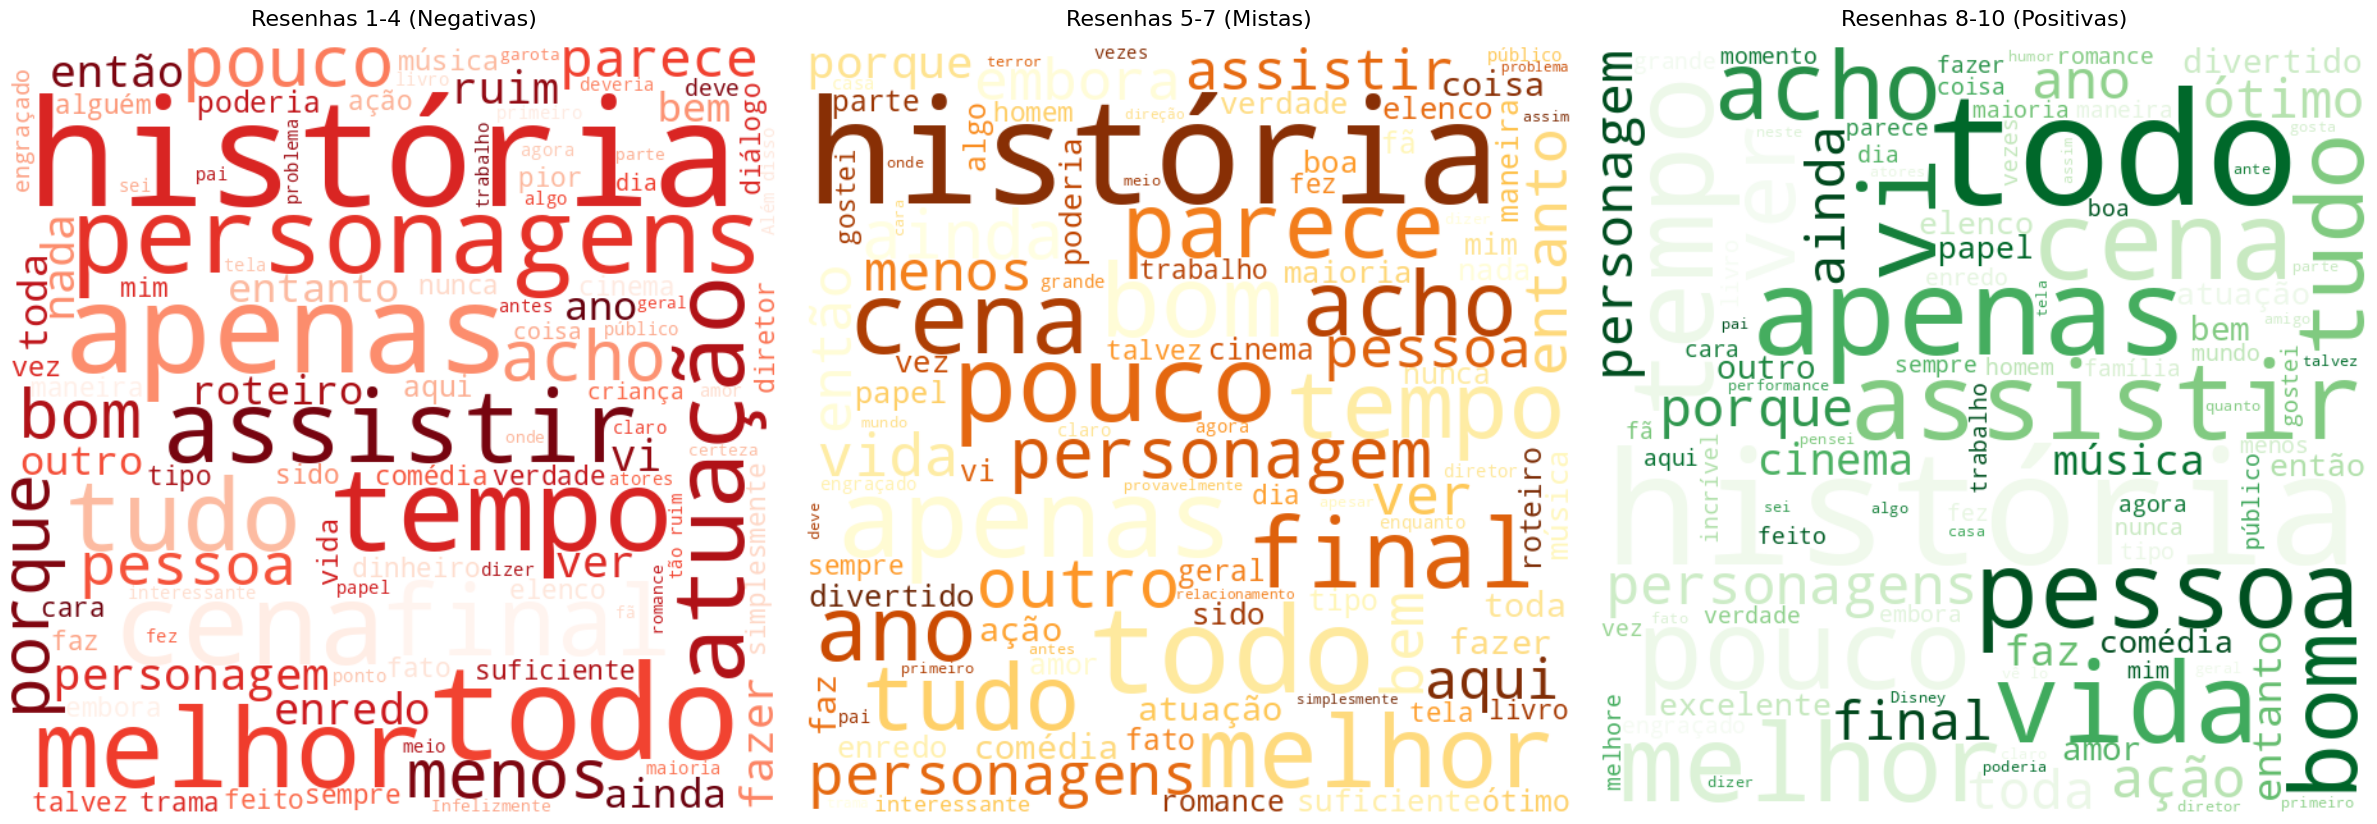

In [53]:
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Baixar as stopwords em português se ainda não tiver
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words_pt = stopwords.words('portuguese')

# Adicionando palavras comuns de cinema que podem poluir a nuvem (opcional)
stop_words_pt.extend(['filme', 'filmes', 'sobre', 'ter', 'ser', 'pode', 'realmente'])

# 2. Definindo a coluna de texto (Resenhas em Português)
coluna_pt = 'Resenhas'

# 3. Preparando os textos por faixa
texto_baixo_pt  = " ".join(df[(df['Ratings'] >= 1) & (df['Ratings'] <= 4)][coluna_pt].astype(str))
texto_medio_pt  = " ".join(df[(df['Ratings'] >= 5) & (df['Ratings'] <= 7)][coluna_pt].astype(str))
texto_alto_pt   = " ".join(df[(df['Ratings'] >= 8) & (df['Ratings'] <= 10)][coluna_pt].astype(str))

# 4. Gerando as nuvens
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

# Função auxiliar para criar a nuvem PT
def criar_nuvem_pt(texto, titulo, cor, eixo):
    wc = WordCloud(
        width=600, height=600,
        background_color='white',
        colormap=cor,
        stopwords=stop_words_pt, # Aplicando as stopwords em português
        max_words=100
    ).generate(texto)
    eixo.imshow(wc, interpolation='bilinear')
    eixo.set_title(titulo, fontsize=16, pad=15)
    eixo.axis('off')

# Plotando as 3
criar_nuvem_pt(texto_baixo_pt, "Resenhas 1-4 (Negativas)", 'Reds', ax1)
criar_nuvem_pt(texto_medio_pt, "Resenhas 5-7 (Mistas)", 'YlOrBr', ax2)
criar_nuvem_pt(texto_alto_pt, "Resenhas 8-10 (Positivas)", 'Greens', ax3)

plt.tight_layout()
plt.show()

###3 DFs com as palavras mais utilizadas

In [54]:
import pandas as pd
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

# 1. Configuração das Stopwords em Português
try:
    nltk.download('stopwords')
    stop_words_pt = set(stopwords.words('portuguese'))
except:
    # Caso esteja sem internet, uma lista básica de fallback
    stop_words_pt = {'de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um', 'para', 'com', 'não', 'uma', 'os', 'no', 'se', 'na', 'por', 'mais', 'as', 'dos', 'como', 'mas', 'foi', 'ao', 'ele', 'das', 'tem', 'à', 'seu', 'sua', 'ou', 'ser', 'quando', 'muito', 'há', 'nos', 'já', 'está', 'eu', 'também', 'só', 'pelo', 'pela', 'até', 'isso', 'ela', 'entre', 'depois', 'sem', 'mesmo', 'aos', 'seus', 'quem', 'nas', 'me', 'esse', 'eles', 'estão', 'você', 'tinha', 'foram', 'essa', 'num', 'nem', 'suas', 'meu', 'minha', 'numa', 'pelos', 'elas', 'havia', 'seja', 'qual', 'será', 'nós', 'tenho', 'lhe', 'deles', 'essas', 'esses', 'pelas', 'este', 'fosse', 'dele', 'tu', 'te', 'vocês', 'vos', 'lhes', 'meus', 'minhas', 'teu', 'tua', 'teus', 'tuas', 'nosso', 'nossa', 'nossos', 'nossas', 'estava', 'estávamos', 'estavam', 'estivera', 'estivéramos', 'esteja', 'estejamos', 'estejam', 'estivesse', 'estivéssemos', 'estivessem', 'estiver', 'estivermos', 'estiverem', 'tenha', 'tenhamos', 'tenham', 'tivesse', 'tivéssemos', 'tivessem', 'tiver', 'tivermos', 'tiverem', 'terei', 'terá', 'teremos', 'terão', 'teria', 'teríamos', 'teriam'}

# Adicionando ruídos específicos de cinema para o Top 20 ser mais limpo
stop_words_pt.update(['filme', 'filmes', 'realmente', 'tão', 'tudo', 'ver', 'visto', 'faz', 'fazer', 'pode', 'sobre', 'história', 'personagem', 'personagens'])

def get_top_20_resenhas(dataframe, notas_range):
    # Filtra por faixa de nota
    sub_df = dataframe[dataframe['Ratings'].between(notas_range[0], notas_range[1])]

    # Junta o texto, passa para minúsculo e remove pontuação básica
    texto_total = " ".join(sub_df['Resenhas'].astype(str).str.lower())
    texto_limpo = re.sub(r'[^a-záàâãéèêíïóôõöúç\s]', '', texto_total)

    # Tokeniza e filtra palavras com menos de 3 letras ou que sejam stopwords
    palavras = [w for w in texto_limpo.split() if w not in stop_words_pt and len(w) > 2]

    # Retorna o DataFrame com as 20 mais comuns
    return pd.DataFrame(Counter(palavras).most_common(20), columns=['Palavra_PT', 'Freq'])

# 2. Gerando os 3 DataFrames para o seu relatório
df_top_1_4 = get_top_20_resenhas(df, (1, 4))
df_top_5_7 = get_top_20_resenhas(df, (5, 7))
df_top_8_10 = get_top_20_resenhas(df, (8, 10))

# 3. Exibição para análise
print("--- TOP 20 RESENHAS: NOTAS 1-4 (DETRATORES) ---")
display(df_top_1_4)

print("\n--- TOP 20 RESENHAS: NOTAS 5-7 (NEUTROS/MISTOS) ---")
display(df_top_5_7)

print("\n--- TOP 20 RESENHAS: NOTAS 8-10 (PROMOTORES) ---")
display(df_top_8_10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


--- TOP 20 RESENHAS: NOTAS 1-4 (DETRATORES) ---


,Palavra_PT,Freq
0,apenas,9560
1,ter,8201
2,ruim,7184
3,melhor,6652
4,tempo,6561
5,bem,6435
6,bom,5956
7,porque,5868
8,nada,5719
9,todos,5571



--- TOP 20 RESENHAS: NOTAS 5-7 (NEUTROS/MISTOS) ---


,Palavra_PT,Freq
0,bem,7437
1,bom,7096
2,apenas,6769
3,pouco,6591
4,ter,6221
5,melhor,5781
6,algumas,5151
7,ainda,5007
8,todos,4975
9,parece,4962



--- TOP 20 RESENHAS: NOTAS 8-10 (PROMOTORES) ---


,Palavra_PT,Freq
0,todos,9137
1,bem,8550
2,apenas,8007
3,pessoas,7243
4,bom,6727
5,melhor,6545
6,assistir,6266
7,pouco,5571
8,vida,5507
9,ainda,5455


###Distribuição percentual por gênero

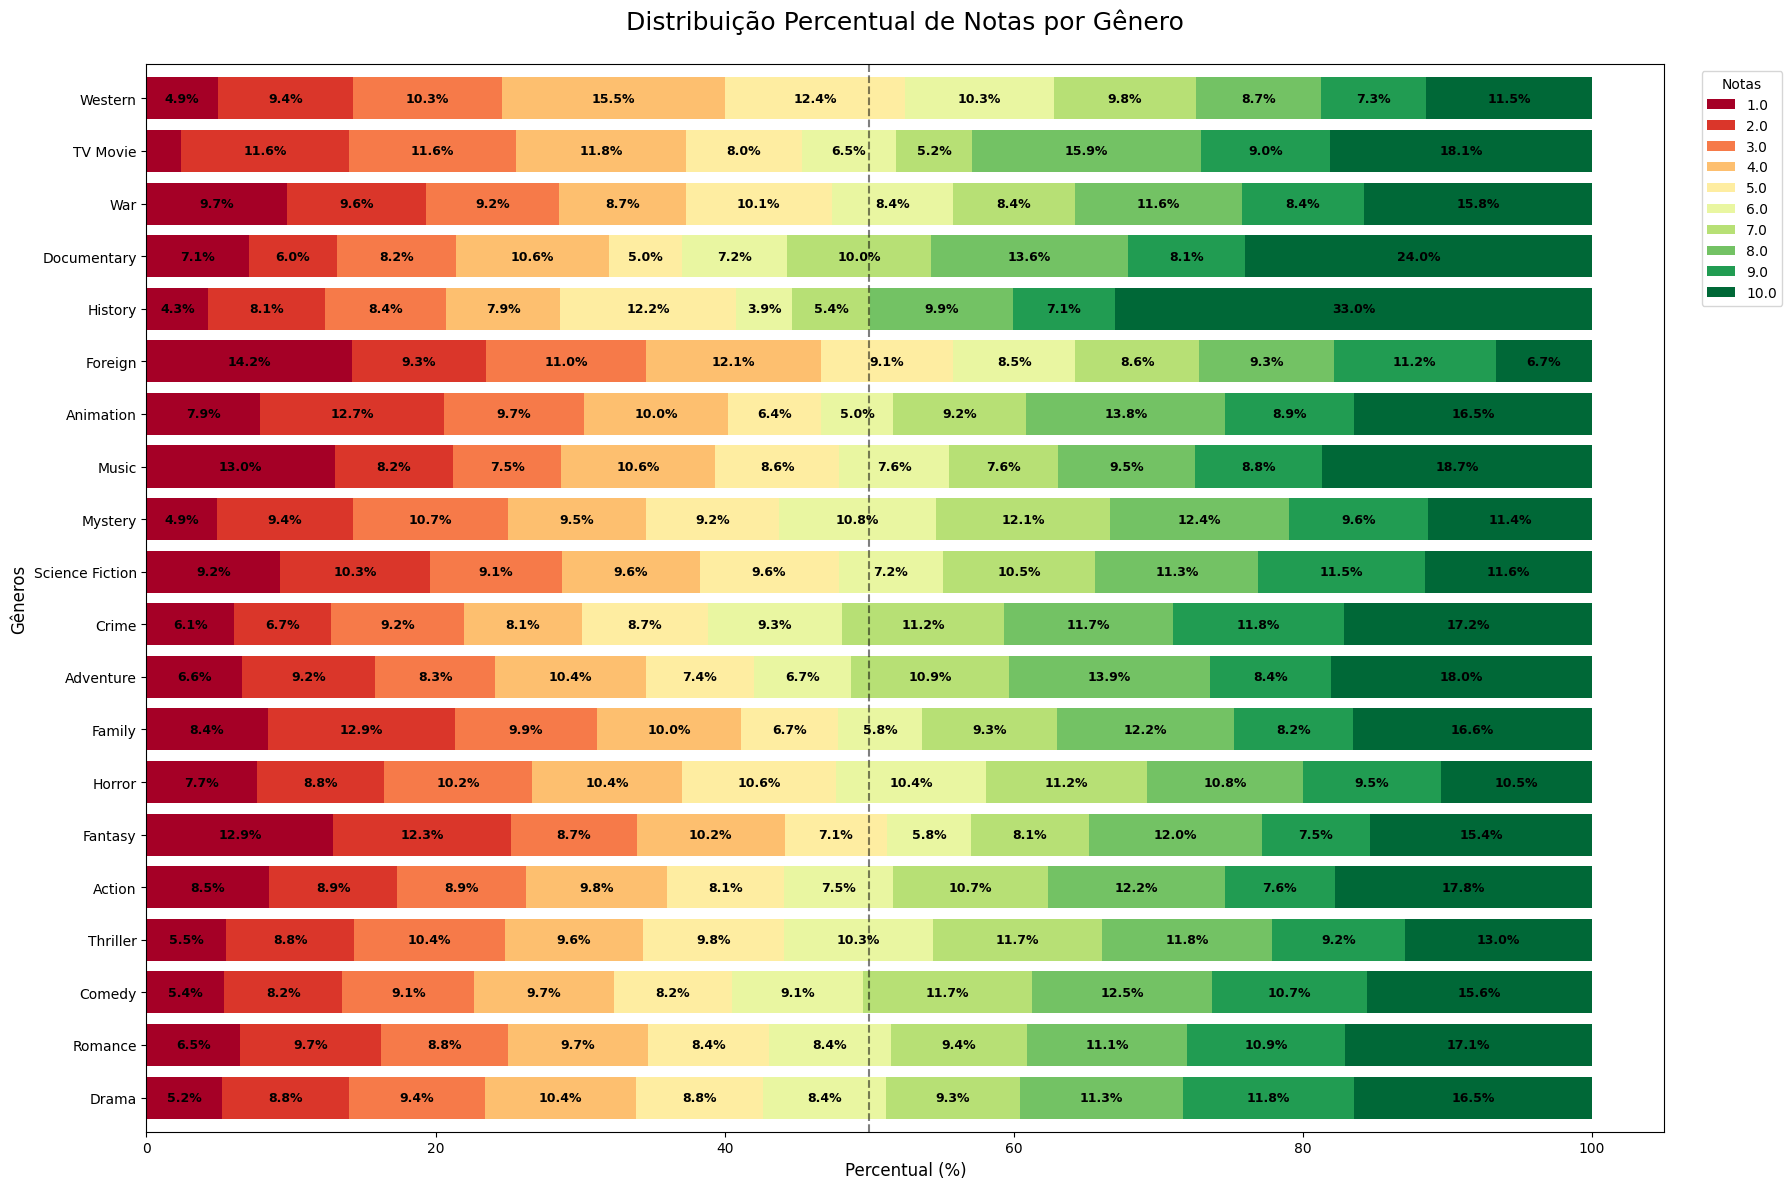

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparação e Crosstab (Percentual por Gênero)
df_gen = df.explode('genres').reset_index(drop=True)
tab_percent = pd.crosstab(df_gen['genres'], df_gen['Ratings'], normalize='index') * 100

# Ordenar pelos gêneros com mais avaliações para melhor visualização
ordem = df_gen['genres'].value_counts().index
tab_percent = tab_percent.reindex(ordem)

# 2. Plotagem
ax = tab_percent.plot(kind='barh', stacked=True, colormap='RdYlGn', figsize=(18, 12), width=0.8)

# 3. ADICIONANDO RÓTULOS DE DADOS EM CADA FATIA
for p in ax.patches:
    width = p.get_width()
    if width > 3.0:  # Só desenha o rótulo se a fatia tiver mais de 3% de largura
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.text(x, y, f'{width:.1f}%',
                ha='center', va='center',
                fontsize=9, color='black', fontweight='bold')

# 4. Ajustes Finais
plt.title('Distribuição Percentual de Notas por Gênero', fontsize=18, pad=25)
plt.xlabel('Percentual (%)', fontsize=12)
plt.ylabel('Gêneros', fontsize=12)
plt.legend(title='Notas', bbox_to_anchor=(1.02, 1), loc='upper left')

# Adiciona linha guia nos 50%
plt.axvline(50, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()